# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-9: Algoritmo de Bernstein-Vazirani (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-9.

### Relación con Deutsch-Jozsa

Bernstein-Vazirani puede verse como una extensión de Deutsch-Jozsa. Comparten el mismo circuito base (H → oráculo → H → medición), pero cambia el **tipo de pregunta**:

| Algoritmo | Pregunta al oráculo | Consultas clásicas | Consultas cuánticas |
|---|---|:---:|:---:|
| Deutsch-Jozsa | ¿La función es balanceada o constante? | $2^{n-1}+1$ | 1 |
| Bernstein-Vazirani | ¿Cuál es la cadena secreta $s$? | $n$ | 1 |

### Problema que resuelve

Existe una función desconocida $f_s: \{0,1\}^n \rightarrow \{0,1\}$ definida por una **cadena secreta** $s = s_0 s_1 \ldots s_{n-1}$:

$$f_s(x) = s \odot x = (s_0 x_0 + s_1 x_1 + \cdots + s_{n-1} x_{n-1}) \mod 2$$

El objetivo es encontrar $s$ consultando $f_s$ el menor número de veces posible.

**Clásicamente:** $n$ consultas — una por bit de la cadena (evaluando $x = 100\ldots0$, $010\ldots0$, etc.)  
**Cuánticamente:** **1 sola consulta** al oráculo → medición directa de $s$.

### Pasos del algoritmo

| Paso | Acción | Estado resultante |
|---|---|---|
| 0 | Inicializar $n$ qubits de entrada + 1 qubit objetivo | $\vert 0\rangle^{\otimes n}\vert 0\rangle$ |
| 1 | H en cada qubit de entrada → superposición uniforme | $\frac{1}{\sqrt{2^n}} \sum_{x} \vert x\rangle \vert 0\rangle$ |
| 2 | X + H en qubit objetivo → $\vert -\rangle$ (phase kickback) | $\frac{1}{\sqrt{2^n}} \sum_{x} \vert x\rangle \vert -\rangle$ |
| 3 | Oracle $U_{f_s}$: CNOT(input$[i]$ → target) para cada $s_i = 1$ | $\frac{1}{\sqrt{2^n}} \sum_{x} (-1)^{s \odot x} \vert x\rangle \vert -\rangle$ |
| 4 | H en cada qubit de entrada → interferencia | Amplitud 1 solo en $\vert s\rangle$, cero en todos los demás |
| 5 | Medir qubits de entrada | Siempre se obtiene $\vert s\rangle$ con probabilidad 1 |

### Por qué funciona

Tras H → oráculo → H, la amplitud del estado $\vert z\rangle$ es:

$$A(z) = \frac{1}{2^n} \sum_{x=0}^{2^n-1} (-1)^{s \odot x + x \odot z} = \frac{1}{2^n} \sum_{x} (-1)^{(s \oplus z) \odot x}$$

Esta suma es $1$ si $z = s$ (interferencia constructiva) y $0$ para todo $z \neq s$ (interferencia destructiva).  
La medición colapsa al único estado $\vert s\rangle$ con certeza.

### Implementación: 6 qubits de entrada + 1 objetivo

Con 6 qubits el dominio de la función tiene $2^6 = 64$ entradas.  
El oráculo aplica CNOT(input$[i]$ → target) para cada posición donde $s_i = 1$.

### Generación de la cadena secreta

En un escenario real la cadena secreta es desconocida — aquí la generamos aleatoriamente para simular el oráculo.

In [1]:
import cirq
import numpy as np


def func_bit_pattern(num_qubits):
    """
    Genera aleatoriamente la cadena secreta s de num_qubits bits.
    Cada bit es 0 o 1 con igual probabilidad.
    """
    return [np.random.randint(0, 2) for _ in range(num_qubits)]

### Oráculo

El oráculo implementa $U_{f_s}\,\vert x\rangle\vert y\rangle = \vert x\rangle\vert y \oplus f_s(x)\rangle$.  
Para cada bit $s_i = 1$ aplica CNOT(input$[i]$ → target), que acumula el producto punto $s \odot x$ en el qubit objetivo.  
Cuando el qubit objetivo está en $\vert -\rangle$, esto produce el phase kickback $(-1)^{s \odot x}$ en los qubits de entrada.

In [2]:
def oracle(circuit, input_qubits, target_qubit, bit_pattern):
    """
    Aplica el oráculo de Bernstein-Vazirani.

    Para cada posición i donde bit_pattern[i] == 1, aplica
    CNOT(input[i] → target), codificando s·x en el qubit objetivo.
    """
    for i, bit in enumerate(bit_pattern):
        if bit == 1:
            circuit.append(cirq.CNOT(input_qubits[i], target_qubit))
    return circuit

### Algoritmo principal

In [3]:
def BV_algorithm(num_qubits, bit_pattern):
    """
    Implementa el algoritmo de Bernstein-Vazirani.

    num_qubits:  número de qubits de entrada (longitud de la cadena secreta)
    bit_pattern: cadena secreta s como lista de enteros 0/1

    Retorna: (circuit, result)
    """
    input_qubits = [cirq.LineQubit(i) for i in range(num_qubits)]
    target_qubit = cirq.LineQubit(num_qubits)

    circuit = cirq.Circuit()

    # Paso 1: H en cada qubit de entrada → superposición uniforme
    circuit.append(cirq.H(q) for q in input_qubits)

    # Paso 2: preparar qubit objetivo en |-⟩ = H|1⟩ para el phase kickback
    circuit.append([cirq.X(target_qubit), cirq.H(target_qubit)])

    # Paso 3: oráculo — codifica la cadena secreta s en la fase de los qubits de entrada
    circuit = oracle(circuit, input_qubits, target_qubit, bit_pattern)

    # Paso 4: H en cada qubit de entrada → interferencia constructiva solo en |s⟩
    circuit.append(cirq.H(q) for q in input_qubits)

    # Paso 5: medir qubits de entrada — el resultado debe ser exactamente s
    circuit.append(cirq.measure(*input_qubits, key='Z'))

    sim = cirq.Simulator()
    result = sim.run(circuit, repetitions=1000)

    return circuit, result

---
## Ejecución con la cadena del libro: `s = 111011`

Usamos la misma cadena secreta del libro para reproducir su salida y verificar la implementación.

In [4]:
SECRET = [1, 1, 1, 0, 1, 1]  # cadena del libro: 111011
NUM_QUBITS = len(SECRET)

print(f"Cadena secreta (oráculo): {''.join(str(b) for b in SECRET)}")

circuit, result = BV_algorithm(NUM_QUBITS, SECRET)
print(circuit)

Cadena secreta (oráculo): 111011
0: ───H───────@───H───────────────────M('Z')───
              │                       │
1: ───H───────┼───@───H───────────────M────────
              │   │                   │
2: ───H───────┼───┼───@───H───────────M────────
              │   │   │               │
3: ───H───H───┼───┼───┼───────────────M────────
              │   │   │               │
4: ───H───────┼───┼───┼───@───H───────M────────
              │   │   │   │           │
5: ───H───────┼───┼───┼───┼───@───H───M────────
              │   │   │   │   │
6: ───X───H───X───X───X───X───X────────────────


### Visualización del circuito

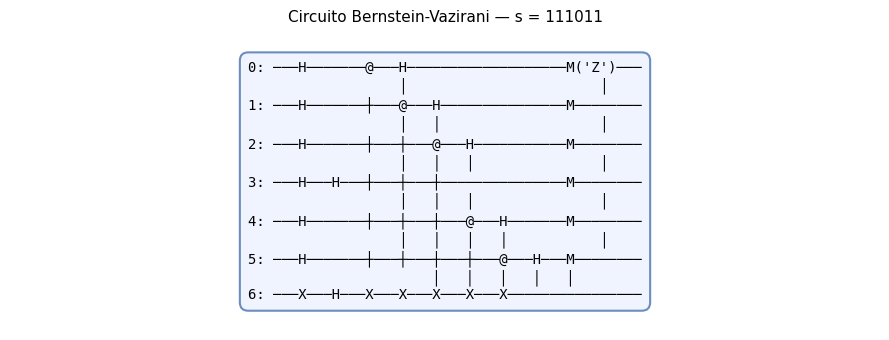

In [5]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=10,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title(f'Circuito Bernstein-Vazirani — s = {"" .join(str(b) for b in SECRET)}', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Histograma de mediciones

La medición debe colapsar **siempre** al estado $\vert s\rangle$. Las 1000 repeticiones deben dar el mismo resultado.

Cadena recuperada: 111011
Cadena secreta:    111011
Coinciden: True


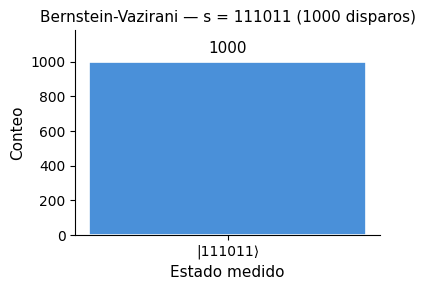

In [6]:
from qml_santanu.common.plot_utils import plot_counts

# Convertir entero a binario con zero-padding para que coincida con la longitud de s
conteos = {
    format(k, f'0{NUM_QUBITS}b'): v
    for k, v in result.histogram(key='Z').items()
}

print(f"Cadena recuperada: {list(conteos.keys())[0]}")
print(f"Cadena secreta:    {''.join(str(b) for b in SECRET)}")
print(f"Coinciden: {list(conteos.keys())[0] == ''.join(str(b) for b in SECRET)}")

plot_counts(conteos, title=f'Bernstein-Vazirani — s = {"" .join(str(b) for b in SECRET)}')

**Interpretación:** las 1000 mediciones dan el mismo resultado — la cadena secreta $s$ completa. No hay error ni ambigüedad: el algoritmo es **determinista**.

---
## Ejecución con cadena aleatoria

El algoritmo funciona para cualquier cadena. Generamos una aleatoria para confirmar que la recuperación es siempre perfecta.

Cadena secreta aleatoria: 010010
Cadena recuperada:        010010
Coinciden: True


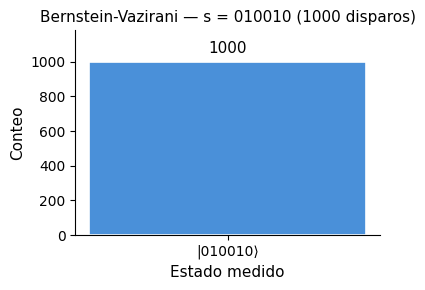

In [7]:
secret_random = func_bit_pattern(NUM_QUBITS)
print(f"Cadena secreta aleatoria: {''.join(str(b) for b in secret_random)}")

circuit_r, result_r = BV_algorithm(NUM_QUBITS, secret_random)

conteos_r = {
    format(k, f'0{NUM_QUBITS}b'): v
    for k, v in result_r.histogram(key='Z').items()
}

recuperada = list(conteos_r.keys())[0]
print(f"Cadena recuperada:        {recuperada}")
print(f"Coinciden: {recuperada == ''.join(str(b) for b in secret_random)}")

plot_counts(conteos_r, title=f'Bernstein-Vazirani — s = {recuperada}')